# Trying the GPU thingies on real data 

### Loading in packages and data 

In [8]:
from pathlib import Path

import pandas as pd
import numpy as np

try:
    from google.colab import drive

    drive.mount("/content/drive")
except ImportError as e:
    raise RuntimeError("This notebook loads data from Google Drive; use Colab or mount Drive yourself.") from e

DATA = Path("/content/drive/MyDrive/GITHUB-COLAB/stk-mat2011/data/processed")
ask_path = DATA / "eurusd_dukascopy_ask_201901.parquet"
bid_path = DATA / "eurusd_dukascopy_bid_201901.parquet"
for p in (ask_path, bid_path):
    if not p.is_file():
        raise FileNotFoundError(p)

bids = pd.read_parquet(bid_path)
bids["datetime"] = pd.to_datetime(bids["datetime"])
bids = bids.sort_values("datetime")
bids = bids.rename(columns={"price": "bid", "volume": "bid_vol"})

asks = pd.read_parquet(ask_path)
asks["datetime"] = pd.to_datetime(asks["datetime"])
asks = asks.sort_values("datetime")
asks = asks.rename(columns={"price": "ask", "volume": "ask_vol"})

print("2. Aligning Asynchronous Ticks (As-Of Merge)...")
# Find the closest Ask for every Bid
quotes = pd.merge_asof(
    bids[['datetime', 'bid', 'bid_vol']], 
    asks[['datetime', 'ask']], 
    on='datetime', 
    direction='backward'
)

# Calculate Mid-Price
quotes['mid_price'] = (quotes['bid'] + quotes['ask']) / 2
quotes.dropna(subset=['mid_price'], inplace=True)
quotes.set_index('datetime', inplace=True)

print(f"Loaded and aligned {len(quotes):,} raw ticks.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2. Aligning Asynchronous Ticks (As-Of Merge)...
Loaded and aligned 3,477,166 raw ticks.


### Clipping the data

In [9]:
print("3. Applying Time Bars and 'Clipping'...")

# 1. Resample the ENTIRE dataset first so the math is continuous
time_bars = quotes['mid_price'].resample('5min').last().ffill()

# 2. Calculate returns on the continuous data
returns = np.log(time_bars / time_bars.shift(1)).dropna() * 10000

# 3. NOW clip the hours out. 
# 10:00 to 19:55 inclusive is exactly 120 bars per day.
start_time = '10:00'
end_time = '19:55' 
returns_clipped = returns.between_time(start_time, end_time)

3. Applying Time Bars and 'Clipping'...


### GPU formatter

In [10]:
print("4. Reshaping into [Days, Bars] Matrix for JAX...")
df_returns = pd.DataFrame({'return': returns_clipped})
df_returns['date'] = df_returns.index.date

expected_bars_per_day = 120 
valid_days = []

for date, group in df_returns.groupby('date'):
    if len(group) == expected_bars_per_day:
        valid_days.append(group['return'].values)

# Convert to a 2D numpy array
matrix_data = np.array(valid_days)

import jax.numpy as jnp
y_jax = jnp.array(matrix_data)

print(f"Data ready for H100! Matrix shape: {y_jax.shape} (Days, Bars)")

4. Reshaping into [Days, Bars] Matrix for JAX...
Data ready for H100! Matrix shape: (30, 120) (Days, Bars)


### AR(1) GPU engine

In [11]:
%%capture
%pip install numpyro

In [ ]:
import jax
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide
from jax.scipy.special import logsumexp
from jax import random
import matplotlib.pyplot as plt

In [ ]:
print(jax.devices())


Compiling AR(1) Model to GPU...
Starting training loop...
Step    0 | Loss (Negative ELBO): 25497.28
Step  500 | Loss (Negative ELBO): 8162.99
Step 1000 | Loss (Negative ELBO): 7279.57
Step 1500 | Loss (Negative ELBO): 6572.14
Step 2000 | Loss (Negative ELBO): 5472.42
Step 2500 | Loss (Negative ELBO): 4095.41
Step 2999 | Loss (Negative ELBO): 2472.49

Training Complete!

--- GPU Learned AR(1) Parameters ---
Transition Matrix:
 [[9.9939996e-01 5.9999997e-04]
 [3.3000000e-03 9.9669999e-01]]
AR(1) Beta 1 (Momentum):
 [-0.0061 -0.2488]
State Volatilities (Sigma):
 [3.0828998 0.0046   ]


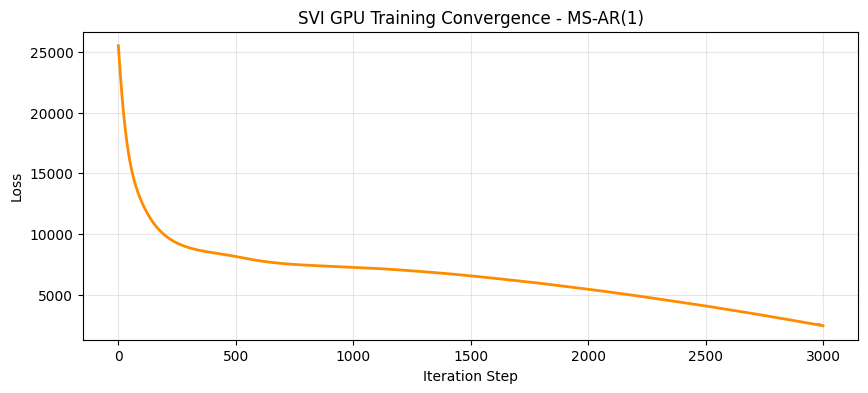

In [12]:
# ==============================================================================
# DEFINE THE MS-AR(1) MODEL FOR THE GPU
# ==============================================================================
def hmm_ar1_model(y):
    n_days, n_bars = y.shape
    n_states = 2

    transition_probs = numpyro.sample("transition_probs", dist.Dirichlet(jnp.ones((n_states, n_states))))
    
    # The AR(1) Parameters for each state
    beta0 = numpyro.sample("beta0", dist.Normal(jnp.zeros(n_states), 0.1)) # Intercept
    beta1 = numpyro.sample("beta1", dist.Normal(jnp.zeros(n_states), 0.5)) # AR(1) Coefficient
    sigma = numpyro.sample("sigma", dist.LogNormal(jnp.zeros(n_states), 1.0)) # Volatility
    
    init_probs = numpyro.sample("init_probs", dist.Dirichlet(jnp.ones(n_states)))

    def forward_one_day(y_day):
        # Step t=0 (No previous day, so we just use beta0)
        log_alpha = jnp.log(init_probs) + dist.Normal(beta0, sigma).log_prob(y_day[0])
        
        def scan_fn(log_alpha_prev, t):
            y_curr = y_day[t]
            y_prev = y_day[t-1] # The AR(1) lookback
            
            # The Autoregressive Equation: mu = beta0 + beta1 * y_{t-1}
            mu_t = beta0 + beta1 * y_prev
            
            log_emission = dist.Normal(mu_t, sigma).log_prob(y_curr)
            log_alpha_next = logsumexp(log_alpha_prev[:, None] + jnp.log(transition_probs), axis=0) + log_emission
            
            return log_alpha_next, None

        # Loop from t=1 to the end of the day
        log_alpha_final, _ = jax.lax.scan(scan_fn, log_alpha, jnp.arange(1, n_bars))
        return logsumexp(log_alpha_final)

    # vmap processes all independent days simultaneously (as requested by advisor)
    log_likes = jax.vmap(forward_one_day)(y)
    numpyro.factor("log_likelihood", jnp.sum(log_likes))

# ==============================================================================
# SVI TRAINING LOOP
# ==============================================================================
print("\nCompiling AR(1) Model to GPU...")
optimizer = numpyro.optim.Adam(step_size=0.005)
guide = autoguide.AutoDelta(hmm_ar1_model)
svi = SVI(hmm_ar1_model, guide, optimizer, loss=Trace_ELBO())

rng_key = random.PRNGKey(42)
svi_state = svi.init(rng_key, y=y_jax)

n_steps = 3000
losses = []

print("Starting training loop...")
for i in range(n_steps):
    svi_state, loss = svi.update(svi_state, y=y_jax)
    losses.append(float(loss))
    if i % 500 == 0 or i == n_steps - 1:
        print(f"Step {i:4d} | Loss (Negative ELBO): {loss:.2f}")

print("\nTraining Complete!")

# Extract Parameters
learned_params = svi.get_params(svi_state)
print("\n--- GPU Learned AR(1) Parameters ---")
print("Transition Matrix:\n", np.round(learned_params['transition_probs_auto_loc'], 4))
print("AR(1) Beta 1 (Momentum):\n", np.round(learned_params['beta1_auto_loc'], 4))
print("State Volatilities (Sigma):\n", np.round(learned_params['sigma_auto_loc'], 4))

# Plot
plt.figure(figsize=(10, 4))
plt.plot(losses, color='darkorange', linewidth=2)
plt.title("SVI GPU Training Convergence - MS-AR(1)")
plt.xlabel("Iteration Step")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
print(jax.devices())